In [1]:
!pip install seaborn scikit-learn


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
None

Missing Values:
age          0
job          0
marital      0
education    0
de

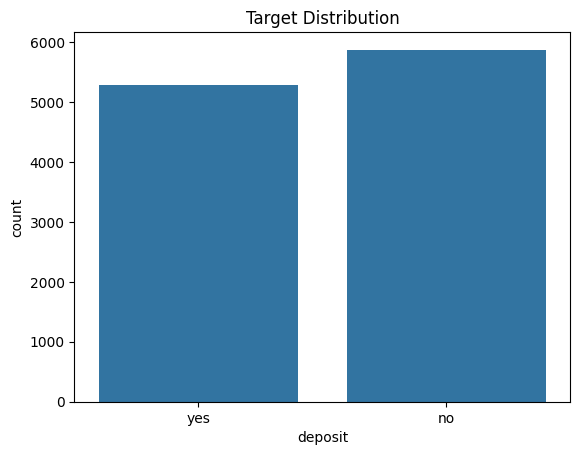

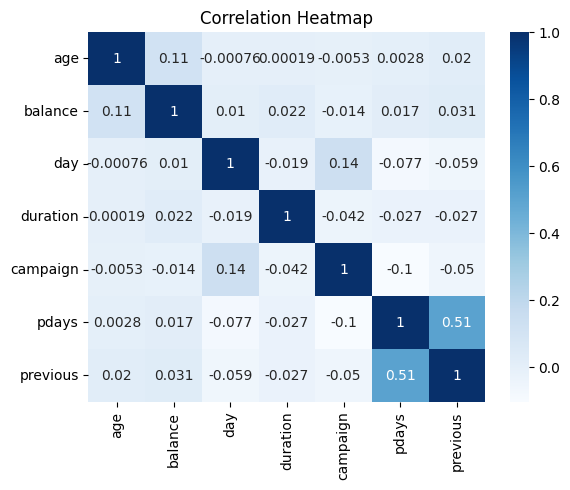


Model Training Complete!

📊 MODEL PERFORMANCE
Accuracy: 0.8620689655172413
Precision: 0.8301056338028169
Recall: 0.8913043478260869
F1 Score: 0.8596171376481313


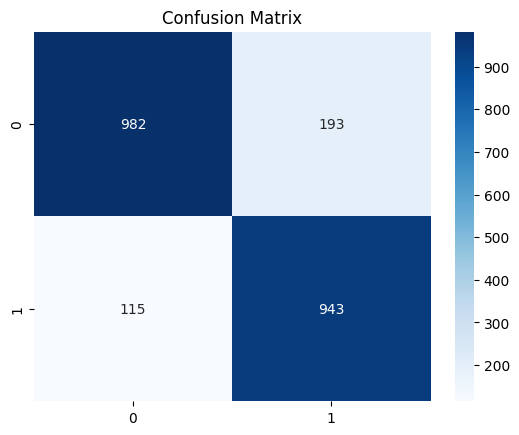


Best Parameters: {'clf__max_depth': 20, 'clf__n_estimators': 200}


'Will Not Subscribe'

In [4]:
# ============================================================
# 📌 BANK MARKETING CLASSIFICATION PROJECT (FULL PIPELINE)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from google.colab import files

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("bank.csv")  # Upload from Kaggle dataset
df.head()

# ============================================================
# 2. EXPLORE DATA
# ============================================================

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

# Target distribution
sns.countplot(x="deposit", data=df)
plt.title("Target Distribution")
plt.show()

# Correlation heatmap (numeric only)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# 3. PREPROCESSING
# ============================================================

# Features and target
X = df.drop("deposit", axis=1)
y = df["deposit"].map({"yes": 1, "no": 0})

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# ============================================================
# 4. TRAIN/TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 5. MODEL TRAINING
# ============================================================

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(random_state=42))
])

model.fit(X_train, y_train)
print("\nModel Training Complete!")

# ============================================================
# 6. EVALUATION
# ============================================================

y_pred = model.predict(X_test)

print("\n📊 MODEL PERFORMANCE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ============================================================
# 7. HYPERPARAMETER TUNING
# ============================================================

param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [5, 10, 20]
}

grid = GridSearchCV(model, param_grid, cv=3, scoring="accuracy")
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

# ============================================================
# 8. SIMPLE DEPLOYMENT (USER INPUT)
# ============================================================

def predict_customer(data_dict):
    sample = pd.DataFrame([data_dict])
    pred = grid.predict(sample)[0]
    return "Will Subscribe" if pred == 1 else "Will Not Subscribe"

# Example prediction
predict_customer({
    "age": 35,
    "job": "technician",
    "marital": "married",
    "education": "secondary",
    "default": "no",
    "balance": 500,
    "housing": "yes",
    "loan": "no",
    "contact": "cellular",
    "day": 15,
    "month": "may",
    "duration": 200,
    "campaign": 1,
    "pdays": 999,
    "previous": 0,
    "poutcome": "unknown"
})